# Bug Severity Classification: Academic Machine Learning Pipeline

This notebook demonstrates a clear, end-to-end machine learning pipeline for classifying software bug severity. It includes data preprocessing, outlier handling, exploratory data analysis, feature engineering (TF-IDF), feature selection (Chi-Square), and model training/evaluation.

## Step 1: Libraries and Setup
We import all necessary libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})
RANDOM_STATE = 42


## Step 2: Data Loading & Preprocessing
We load the dataset, handle missing values, and combine the text features (title and description) into a single feature for NLP tasks.

In [2]:
data_path = 'data/bug_dataset_50k.csv'
if not os.path.exists(data_path):
    print("Dataset not found. Please ensure it is located at 'data/bug_dataset_50k.csv'")

df = pd.read_csv(data_path)
print(f"Original Dataset Shape: {df.shape}")

# Handle missing values
df['title'] = df['title'].fillna('')
df['description'] = df['description'].fillna('')

categorical_cols = ['bug_category', 'tech_stack', 'environment', 'developer_role', 'bug_domain']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown').astype(str).str.lower().str.strip()

# Feature Engineering: Combine text features
df['full_text'] = (df['title'] + " " + df['description']).str.lower()

# Calculate word count for outlier detection
df['desc_word_count'] = df['full_text'].apply(lambda x: len(x.split()))

print("Data preprocessing complete.")


Original Dataset Shape: (50000, 14)
Data preprocessing complete.


## Step 3: Exploratory Data Analysis (EDA)
We visualize the distribution of our target variable (severity) to check for class imbalances.

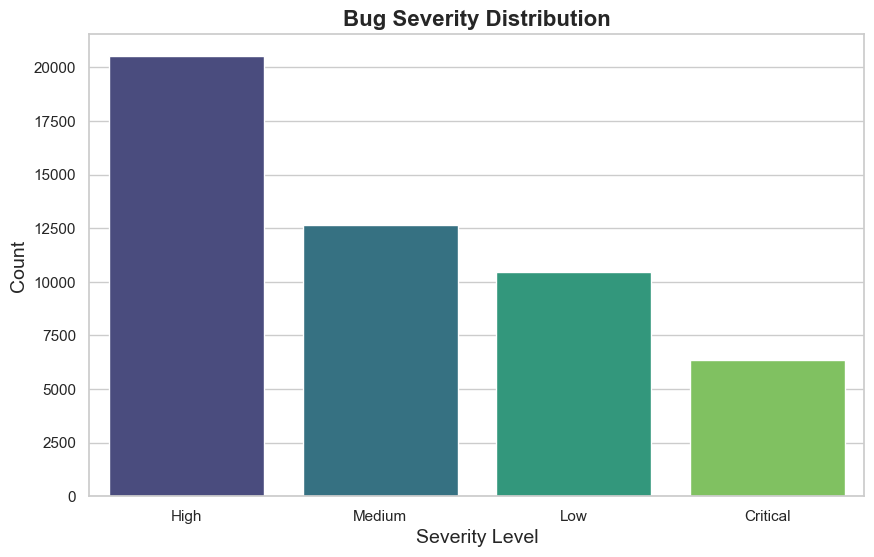

Class Distribution:
severity
High        20517
Medium      12667
Low         10475
Critical     6341
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='severity', order=df['severity'].value_counts().index, palette='viridis')
plt.title("Bug Severity Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Severity Level", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.show()

print("Class Distribution:")
print(df['severity'].value_counts())


**Interpretation:** This chart displays the distribution of bug severities. If the classes are heavily imbalanced, it might affect the performance of certain models, making metrics like F1-Score more important than standard accuracy.

## Step 4: Outlier Detection and Removal
We use a boxplot to detect extremely long descriptions which might act as noise. We then remove them using the Interquartile Range (IQR) method.

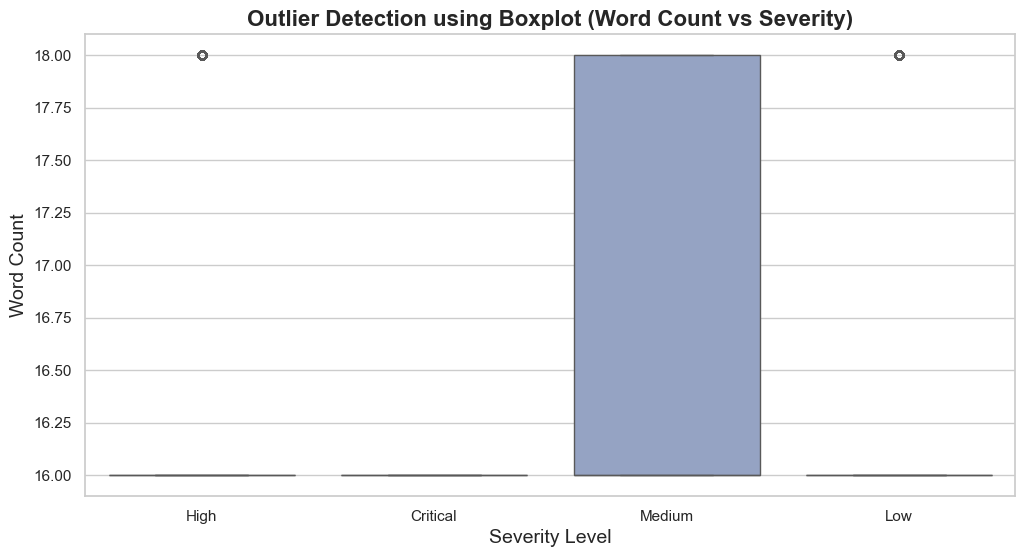

Removed 9261 outlier records. Remaining records: 40739


In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='severity', y='desc_word_count', data=df, palette='Set2')
plt.title("Outlier Detection using Boxplot (Word Count vs Severity)", fontsize=16, fontweight='bold')
plt.xlabel("Severity Level", fontsize=14)
plt.ylabel("Word Count", fontsize=14)
plt.show()

# IQR Method for Outlier Removal
Q1 = df['desc_word_count'].quantile(0.25)
Q3 = df['desc_word_count'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

initial_count = len(df)
df = df[df['desc_word_count'] <= upper_limit].copy()
print(f"Removed {initial_count - len(df)} outlier records. Remaining records: {len(df)}")


**Interpretation:** The boxplot helps us identify bugs with abnormally long text descriptions. These outliers can cause noise and slow down NLP models (like TF-IDF). We removed the upper outliers using the IQR statistical method to stabilize the model training.

## Step 5: Feature Engineering & Train/Test Split
We encode the target variable, split the data to prevent data leakage, and apply TF-IDF and OneHotEncoding.

In [5]:
# Encode Target
target_le = LabelEncoder()
df['target'] = target_le.fit_transform(df['severity'])

# Separate Features and Target
X = df.drop(columns=['severity', 'target'])
y = df['target']

# Train/Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train samples: {len(X_train_raw)}, Test samples: {len(X_test_raw)}")

# Preprocessor
transformers = [
    ('cat', OneHotEncoder(handle_unknown='ignore'), [col for col in categorical_cols if col in X.columns]),
    ('text', TfidfVectorizer(max_features=5000, stop_words='english'), 'full_text')
]
preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

X_train_transformed = preprocessor.fit_transform(X_train_raw)
X_test_transformed = preprocessor.transform(X_test_raw)
print(f"Total features after encoding: {X_train_transformed.shape[1]}")


Train samples: 32591, Test samples: 8148


Total features after encoding: 69


## Step 6: Feature Selection (Chi-Square)
We use the Chi-Square statistical test to select the top features most correlated with the target variable, and visualize the most important ones.

Selected feature matrix shape: (32591, 69)


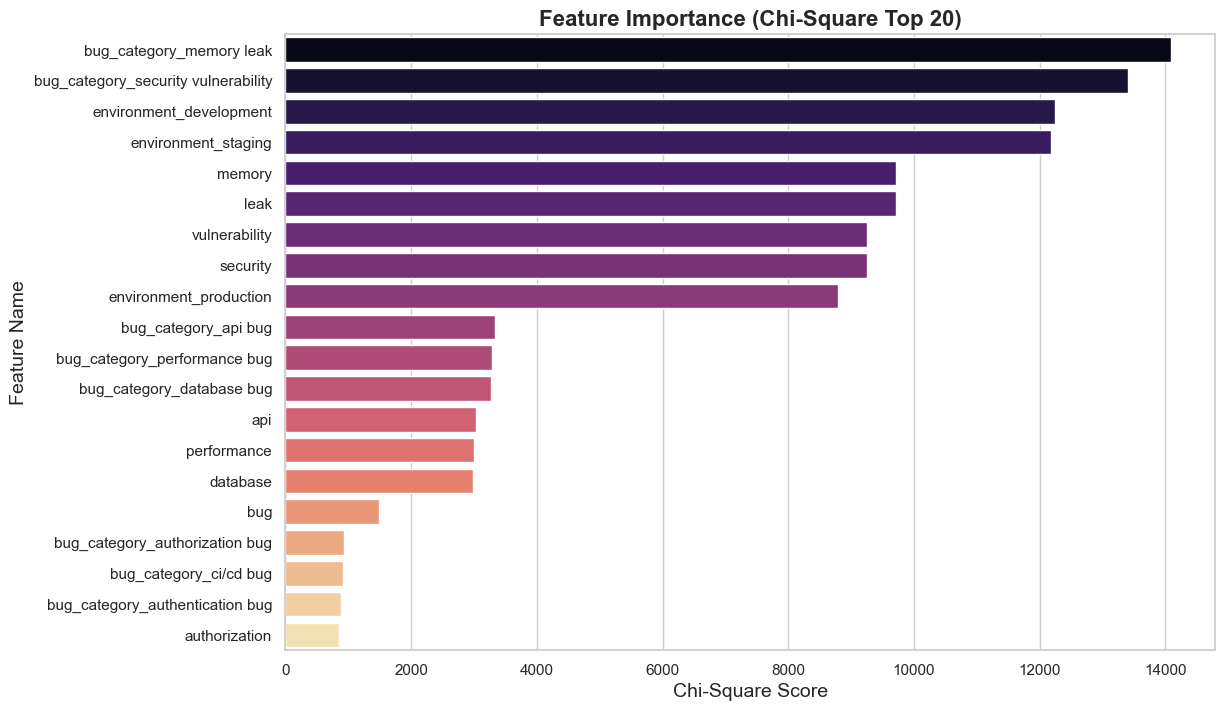

In [6]:
k_features = min(2000, X_train_transformed.shape[1])
selector = SelectKBest(score_func=chi2, k=k_features)
X_train_selected = selector.fit_transform(X_train_transformed, y_train)
X_test_selected = selector.transform(X_test_transformed)
print(f"Selected feature matrix shape: {X_train_selected.shape}")

# Visualize Top Features
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out()
text_names = preprocessor.named_transformers_['text'].get_feature_names_out()
all_feature_names = np.concatenate([cat_names, text_names])

scores = selector.scores_
indices = np.argsort(scores)[::-1][:20]

plt.figure(figsize=(12, 8))
sns.barplot(x=scores[indices], y=all_feature_names[indices], palette='magma')
plt.title("Feature Importance (Chi-Square Top 20)", fontsize=16, fontweight='bold')
plt.xlabel("Chi-Square Score", fontsize=14)
plt.ylabel("Feature Name", fontsize=14)
plt.show()


**Interpretation:** The Chi-Square test determines which words and categorical features have the strongest relationship with bug severity. The bar chart shows the top 20 most influential features. Words like 'crash' or 'fatal' typically have high scores as they are strong indicators of Critical bugs.

## Step 7: Model Training & Evaluation
We train two models (Naive Bayes and Random Forest) and compare their performance using Accuracy, F1-Score, and Confusion Matrices.


Training Naive Bayes...
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00      1249
        High       1.00      1.00      1.00      3530
         Low       1.00      1.00      1.00      1612
      Medium       1.00      1.00      1.00      1757

    accuracy                           1.00      8148
   macro avg       1.00      1.00      1.00      8148
weighted avg       1.00      1.00      1.00      8148



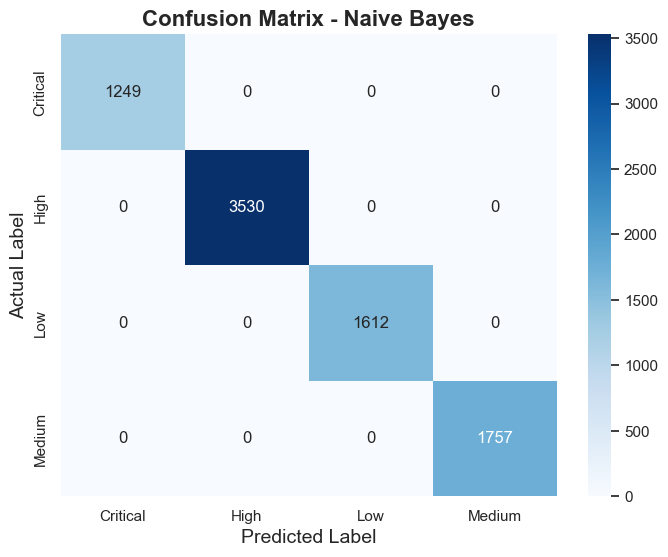


Training Random Forest...


              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00      1249
        High       1.00      1.00      1.00      3530
         Low       1.00      1.00      1.00      1612
      Medium       1.00      1.00      1.00      1757

    accuracy                           1.00      8148
   macro avg       1.00      1.00      1.00      8148
weighted avg       1.00      1.00      1.00      8148



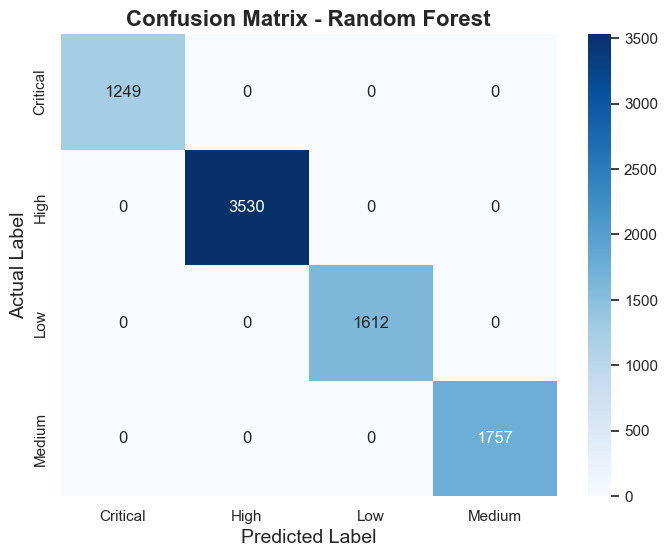


--- Model Comparison Summary ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0


In [7]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"\n{'='*50}\nTraining {name}...\n{'='*50}")
    model.fit(X_train_selected, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test_selected)
    
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(classification_report(y_test, y_pred, target_names=target_le.classes_))
    
    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_le.classes_, yticklabels=target_le.classes_, annot_kws={"size": 12})
    plt.title(f"Confusion Matrix - {name}", fontsize=16, fontweight='bold')
    plt.ylabel('Actual Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.show()

print("\n--- Model Comparison Summary ---")
results_df = pd.DataFrame(results)
import IPython.display as display
display.display(results_df)


**Interpretation:**\n- The **Classification Report** shows the Precision, Recall, and F1-score for each severity class.\n- The **Confusion Matrix** shows where the model is making mistakes. The diagonal represents correct predictions, while off-diagonal numbers represent misclassifications.\n- **Random Forest** generally performs better at capturing complex, non-linear relationships in the text compared to **Naive Bayes**, which assumes feature independence.